# Laboratorio 2 - Minería de Datos

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import seaborn as sb
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
import skfuzzy as fuzz
import pylab
import sklearn.mixture as mixture
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import random
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans, AgglomerativeClustering


In [5]:
#importar csv
df = pd.read_csv('movies_2026.csv', encoding='latin-1')
pd.options.display.float_format = '{:,.0f}'.format

## 1. Clustering

In [ ]:
# 1.1. Preprocesamiento del dataset
vars_cluster = [
    'budget',
    'revenue',
    'popularity',
    'runtime',
    'voteAvg',
    'voteCount',
    'actorsAmount',
    'castWomenAmount',
    'castMenAmount',
    'genresAmount',
    'productionCoAmount',
    'productionCountriesAmount'
]

#Escalar datos
X = df[vars_cluster].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 1.2. Estadístico de Hopkings y la VAT 
def hopkins(X):
    from sklearn.neighbors import NearestNeighbors
    import random
    
    d = X.shape[1]
    n = X.shape[0]
    m = int(0.1 * n)
    
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    
    rand_X = np.random.uniform(np.min(X, axis=0),
                               np.max(X, axis=0),
                               (m,d))
    
    u_dist = []
    w_dist = []
    
    for j in range(m):
        u_dist.append(nbrs.kneighbors([rand_X[j]], 2, return_distance=True)[0][0][1])
        w_dist.append(nbrs.kneighbors([X[np.random.randint(0,n)]], 2, return_distance=True)[0][0][1])
    
    H = sum(u_dist) / (sum(u_dist) + sum(w_dist))
    return H

hopkins(X_scaled)

np.float64(0.990173491021695)

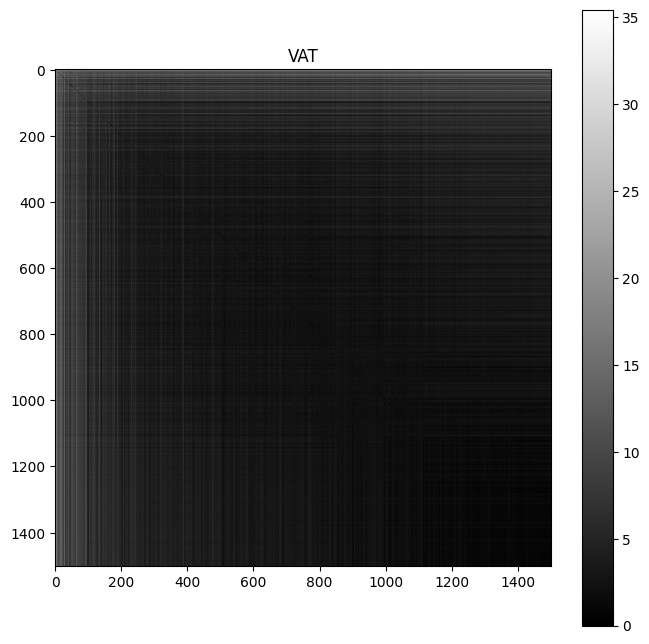

In [ ]:
#VAT
X_sample = X_scaled[np.random.choice(X_scaled.shape[0], 1500, replace=False)]
dist_matrix = squareform(pdist(X_sample))

def VAT(D):
    N = D.shape[0]
    J = list(range(N))
    
    I = []
    
    # Paso inicial
    y = np.argmax(np.sum(D, axis=1))
    I.append(y)
    J.remove(y)
    
    while J:
        j = max(J, key=lambda j: min([D[j, i] for i in I]))
        I.append(j)
        J.remove(j)
    
    D_reordered = D[np.ix_(I, I)]
    return D_reordered


D_vat = VAT(dist_matrix)

plt.figure(figsize=(8,8))
plt.imshow(D_vat, cmap='gray')
plt.title("VAT")
plt.colorbar()
plt.show()

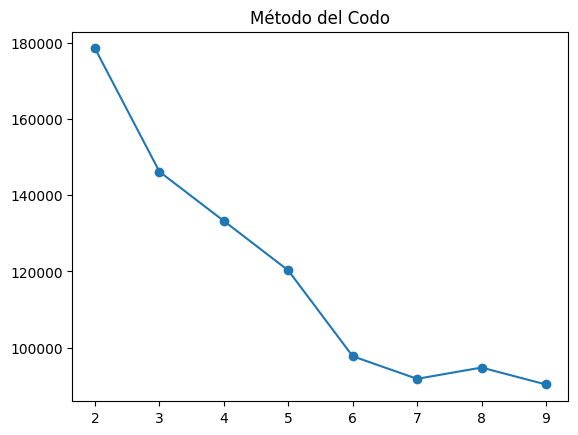

In [ ]:
# 1.3. Número de grupos a formar

inertia = []
K = range(2,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Método del Codo")
plt.show()

In [ ]:
# 1.4. Algoritmos k-medias y clustering jerárquico
##k-means
kmeans = KMeans(n_clusters=4, random_state=42)
labels_k = kmeans.fit_predict(X_scaled)

##Jerárquico
hc = AgglomerativeClustering(n_clusters = 4)
labels_h = hc.fit_predict(X_scaled)

In [ ]:
# 1.5. Calidad del agrupamiento
print("KMeans:", silhouette_score(X_scaled, labels_k))
print("Jerárquico:", silhouette_score(X_scaled, labels_h))

KMeans: 0.3555813718998619
Jerárquico: 0.3533651543189654


In [ ]:
# 1.6.  Interprete los grupos 
df_cluster = df.loc[X.index].copy()
df_cluster['Cluster'] = labels_k

df_cluster.groupby('Cluster')[vars_cluster].mean()

,budget,revenue,popularity,runtime,voteAvg,voteCount,actorsAmount,castWomenAmount,castMenAmount,genresAmount,productionCoAmount,productionCountriesAmount
Cluster,,,,,,,,,,,,
0,"9,673,327","21,752,601",37,100,6,722,23,6,"16,041",3,3,2
1,"100,090,349","385,347,334",107,121,7,"6,958",61,14,70,3,4,2
2,"6,556","3,818",1,26,1,2,4,0,"1,060",1,1,1
3,"105,000,000","354,211,969","6,417",123,7,"2,351",33,10,18,3,3,2


## 2. Reglas de Asociación

In [8]:
#Budget
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")
df["budget_clean"] = df["budget"].replace(0, np.nan)

#revenue
df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")
df["revenue_clean"] = df["revenue"].replace(0, np.nan)

#votecount
df["voteCount"] = pd.to_numeric(df["voteCount"], errors="coerce")
df["voteCount_clean"] = df["voteCount"].replace(0, np.nan)

In [9]:
#Popularity
df["popularity_cat"] = pd.qcut(df["popularity"], 4,
                               labels=["Muy Baja", "Baja", "Alta", "Muy Alta"],
                               duplicates="drop")

#Budget
df["budget_cat"] = pd.qcut(
    df["budget_clean"].dropna(),
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)
df["budget_cat"] = df["budget_cat"].astype(object)
df.loc[df["budget"] == 0, "budget_cat"] = "No Reportado"

#Revenue
df["revenue_cat"] = pd.qcut(
    df["revenue_clean"],
    q=3,
    labels=["Moderado", "Exitoso", "Blockbuster"],
    duplicates="drop"
)
df["revenue_cat"] = df["revenue_cat"].astype(object)
df.loc[df["revenue"] == 0, "revenue_cat"] = "Sin Ingresos"

#Runtime
df["runtime_cat"] = pd.cut(df["runtime"],
                           bins=[0, 90, 120, 150, df["runtime"].max()],
                           labels=["Corta", "Media", "Larga", "Muy Larga"])

#Vote Average
df["voteAvg_cat"] = pd.cut(df["voteAvg"],
                           bins=[0,5,6.5,8,10],
                           labels=["Mala", "Regular", "Buena", "Excelente"])

#Vote Count
df["voteCount_rank"] = df["voteCount_clean"].rank(method="first")
df["voteCount_cat"] = pd.qcut(
    df["voteCount_rank"],
    q=3,
    labels=["Pocos Votos", "Medio", "Muchos Votos"]
)
df["voteCount_cat"] = df["voteCount_cat"].astype(object)
df.loc[df["voteCount"] == 0, "voteCount_cat"] = "Sin Votos"

#Actors Amount
df["actorsAmount_cat"] = pd.cut(df["actorsAmount"],
                                bins=[0,5,10,20,df["actorsAmount"].max()],
                                labels=["Elenco Pequeño", "Medio", "Grande", "Muy Grande"])

#Women Ratio
df["women_ratio"] = df["castWomenAmount"] / (
    df["castWomenAmount"] + df["castMenAmount"]
)
df["women_ratio"] = df["women_ratio"].fillna(0)

df["women_ratio_cat"] = pd.cut(df["women_ratio"],
                               bins=[-0.01, 0.3, 0.6, 1.01],
                               labels=["Mayoría Hombres", "Mixto", "Mayoría Mujeres"])

#Production Countries
df["productionCountries_cat"] = pd.cut(
    df["productionCountriesAmount"],
    bins=[0,1,3,df["productionCountriesAmount"].max()],
    labels=["Nacional", "Coproducción", "Multinacional"]
)

# Décadas
df["release_decade"] = ((df["releaseYear"] // 10) * 10).astype(str) + "s"

In [12]:
cols_apriori = [
    "popularity_cat",
    "budget_cat",
    "revenue_cat",
    "runtime_cat",
    "voteAvg_cat",
    "voteCount_cat",
    "actorsAmount_cat",
    "women_ratio_cat",
    "productionCountries_cat",
    "release_decade",
    "genres",
    "originalLanguage"
]

df_ap = df[cols_apriori].copy()

df_ap = df_ap.dropna()

df_ap = pd.get_dummies(df_ap).astype(int)

df_ap = df_ap.astype(bool)

print("Columnas antes:", df_ap.shape[1])

# Mantener solo columnas que aparecen en al menos 200 películas
df_ap = df_ap.loc[:, df_ap.sum() > 200]

print("Columnas después:", df_ap.shape[1])

Columnas antes: 2515
Columnas después: 48


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    df_ap,
    min_support=0.01, #1%
    use_colnames=True,
    low_memory=True,
    max_len=2
)

pd.set_option("display.float_format", "{:.6f}".format)
frequent_itemsets.head()

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

In [35]:
len(rules)

169

In [21]:
rules_interesantes = rules[
    (rules["lift"] > 1.2) &
    (rules["confidence"] > 0.6)
].copy()

rules_interesantes = rules_interesantes.sort_values(
    "lift", ascending=False
)

rules_interesantes.head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,(popularity_cat_Baja),(release_decade_2020.0s),0.069690,0.193002,0.058471,0.839018,4.347186,1.000000,0.045021,5.012959,0.827645,0.286313,0.800517,0.570987
16,(budget_cat_Alto),(revenue_cat_Blockbuster),0.204887,0.170945,0.130348,0.636195,3.721634,1.000000,0.095324,2.278844,0.919744,0.530984,0.561181,0.699354
17,(revenue_cat_Blockbuster),(budget_cat_Alto),0.170945,0.204887,0.130348,0.762514,3.721634,1.000000,0.095324,3.348041,0.882090,0.530984,0.701318,0.699354
2,(popularity_cat_Baja),(voteCount_cat_Pocos Votos),0.069690,0.267446,0.063510,0.911323,3.407500,1.000000,0.044872,8.260952,0.759456,0.232106,0.878949,0.574396
113,(actorsAmount_cat_Elenco Pequeño),(voteCount_cat_Pocos Votos),0.078722,0.267446,0.063605,0.807971,3.021059,1.000000,0.042551,3.814808,0.726155,0.225101,0.737864,0.522898
117,(genres_Documentary),(voteCount_cat_Pocos Votos),0.021012,0.267446,0.015878,0.755656,2.825450,1.000000,0.010258,2.998044,0.659940,0.058249,0.666449,0.407512
46,(revenue_cat_Blockbuster),(voteCount_cat_Muchos Votos),0.170945,0.367085,0.160297,0.937709,2.554473,1.000000,0.097545,10.160546,0.734004,0.424364,0.901580,0.687192
116,(release_decade_2020.0s),(voteCount_cat_Pocos Votos),0.193002,0.267446,0.126640,0.656158,2.453418,1.000000,0.075022,2.130493,0.734086,0.379379,0.530625,0.564837
114,(actorsAmount_cat_Medio),(voteCount_cat_Pocos Votos),0.155068,0.267446,0.100589,0.648682,2.425466,1.000000,0.059117,2.085157,0.695568,0.312463,0.520420,0.512396
74,(actorsAmount_cat_Elenco Pequeño),(runtime_cat_Corta),0.078722,0.293021,0.053717,0.682367,2.328727,1.000000,0.030650,2.225773,0.619336,0.168909,0.550718,0.432845


In [22]:
rules_interesantes["antecedents"] = rules_interesantes["antecedents"].apply(lambda x: ", ".join(list(x)))
rules_interesantes["consequents"] = rules_interesantes["consequents"].apply(lambda x: ", ".join(list(x)))

rules_interesantes[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]].head(10)

,antecedents,consequents,support,confidence,lift
4,popularity_cat_Baja,release_decade_2020.0s,0.058471,0.839018,4.347186
16,budget_cat_Alto,revenue_cat_Blockbuster,0.130348,0.636195,3.721634
17,revenue_cat_Blockbuster,budget_cat_Alto,0.130348,0.762514,3.721634
2,popularity_cat_Baja,voteCount_cat_Pocos Votos,0.063510,0.911323,3.407500
113,actorsAmount_cat_Elenco Pequeño,voteCount_cat_Pocos Votos,0.063605,0.807971,3.021059
117,genres_Documentary,voteCount_cat_Pocos Votos,0.015878,0.755656,2.825450
46,revenue_cat_Blockbuster,voteCount_cat_Muchos Votos,0.160297,0.937709,2.554473
116,release_decade_2020.0s,voteCount_cat_Pocos Votos,0.126640,0.656158,2.453418
114,actorsAmount_cat_Medio,voteCount_cat_Pocos Votos,0.100589,0.648682,2.425466
74,actorsAmount_cat_Elenco Pequeño,runtime_cat_Corta,0.053717,0.682367,2.328727


In [32]:
len(rules_interesantes)

80

In [ ]:
frequent_itemsets_A = apriori(
    df_ap,
    min_support=0.02,   # 2%
    use_colnames=True,
    low_memory=True,
    max_len=2
)

rules_A = association_rules(
    frequent_itemsets_A,
    metric="confidence",
    min_threshold=0.7
)

len(rules_A)

91

In [36]:
rules_interesantesA = rules_A[
    (rules_A["lift"] > 1.2) &
    (rules_A["confidence"] > 0.6)
].copy()

rules_interesantesA = rules_interesantesA.sort_values(
    "lift", ascending=False
)

rules_interesantesA.head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,(popularity_cat_Baja),(release_decade_2020.0s),0.069690,0.193002,0.058471,0.839018,4.347186,1.000000,0.045021,5.012959,0.827645,0.286313,0.800517,0.570987
10,(revenue_cat_Blockbuster),(budget_cat_Alto),0.170945,0.204887,0.130348,0.762514,3.721634,1.000000,0.095324,3.348041,0.882090,0.530984,0.701318,0.699354
2,(popularity_cat_Baja),(voteCount_cat_Pocos Votos),0.069690,0.267446,0.063510,0.911323,3.407500,1.000000,0.044872,8.260952,0.759456,0.232106,0.878949,0.574396
62,(actorsAmount_cat_Elenco Pequeño),(voteCount_cat_Pocos Votos),0.078722,0.267446,0.063605,0.807971,3.021059,1.000000,0.042551,3.814808,0.726155,0.225101,0.737864,0.522898
28,(revenue_cat_Blockbuster),(voteCount_cat_Muchos Votos),0.170945,0.367085,0.160297,0.937709,2.554473,1.000000,0.097545,10.160546,0.734004,0.424364,0.901580,0.687192
11,(budget_cat_Alto),(voteCount_cat_Muchos Votos),0.204887,0.367085,0.172371,0.841299,2.291838,1.000000,0.097160,3.988105,0.708917,0.431359,0.749254,0.655433
39,(actorsAmount_cat_Elenco Pequeño),(revenue_cat_Sin Ingresos),0.078722,0.499430,0.074444,0.945652,1.893465,1.000000,0.035128,9.210496,0.512188,0.147792,0.891428,0.547355
38,(voteCount_cat_Pocos Votos),(revenue_cat_Sin Ingresos),0.267446,0.499430,0.246815,0.922858,1.847825,1.000000,0.113244,6.488962,0.626334,0.474589,0.845892,0.708526
1,(popularity_cat_Baja),(revenue_cat_Sin Ingresos),0.069690,0.499430,0.062750,0.900409,1.802875,1.000000,0.027944,5.026276,0.478690,0.123920,0.801046,0.513026
29,(revenue_cat_Blockbuster),(actorsAmount_cat_Muy Grande),0.170945,0.483362,0.148602,0.869299,1.798444,1.000000,0.065974,3.952831,0.535506,0.293852,0.747017,0.588367


In [ ]:
frequent_itemsets_C = apriori(
    df_ap,
    min_support=0.005,   # 0.5%
    use_colnames=True,
    low_memory=True,
    max_len=2
)

rules_C = association_rules(
    frequent_itemsets_C,
    metric="confidence",
    min_threshold=0.5
)

len(rules_C)

292